#  Advanced Movie Recommendation System — Enhanced Dataset Edition
> **TF-IDF (Keyword-Heavy Soup) · Sentence-BERT (Overview Semantics) · SVD Collaborative Filtering**  
> **Temporal-Era Filtering · Language & Adult Filters · Hybrid Scorer v3**
>
> Re-engineered for the new rich dataset: `id · title · language · overview · genres · keywords ·  
> cast · director · release_date · runtime · popularity · vote_average · vote_count · adult`

---
### 📋 Table of Contents
1. [Environment Setup](#1-environment-setup)
2. [Data Loading & Schema Parsing](#2-data-loading--schema-parsing)
3. [Preprocessing & Feature Engineering](#3-preprocessing--feature-engineering)
4. [Exploratory Data Analysis](#4-exploratory-data-analysis)
5. [Soup Construction — Keyword-Heavy Weighting](#5-soup-construction)
6. [Content-Based Filtering (TF-IDF)](#6-content-based-filtering)
7. [Semantic Filtering (Sentence-BERT on Overview)](#7-semantic-filtering-sbert)
8. [Temporal-Aware Era Engine](#8-temporal-era-engine)
9. [Collaborative Filtering (SVD on Keyword Matrix)](#9-collaborative-filtering)
10. [Hybrid Recommender v3](#10-hybrid-recommender-v3)
11. [Language & Adult Filters](#11-language--adult-filters)
12. [Evaluation & Benchmarking](#12-evaluation--benchmarking)
13. [Interactive Demo](#13-interactive-demo)

---
### 🔄 Implementation Flow

```
Raw CSV (new schema)
      │
      ▼
 ① Parse list columns (ast.literal_eval)
    genres · keywords · cast · spoken_languages · production_companies
      │
      ▼
 ② Feature Engineering
    year (from release_date) · era_bucket · bayesian_weighted_rating
    popularity_norm · cast_top5 · primary_genre
      │
      ├──────────────────────────────────────────────────────────────┐
      ▼                                                              ▼
 ③ Keyword-Heavy Soup                                    ④ Natural Language Description
    keywords×4 · genres×3 · cast×2                         overview + tagline (full prose)
    director×2 · overview_tokens×2 · tagline×1              → fed to Sentence-BERT
      │                                                              │
      ▼                                                              ▼
 ⑤ TF-IDF Matrix (1-2 grams)                           ⑥ SBERT Dense Embeddings
    cosine_similarity → Content Score                      cosine_similarity → Semantic Score
      │                                                              │
      └─────────────────┬────────────────────────────────────────────┘
                        │
                        ▼
 ⑦ SVD Collaborative Filtering
    TruncatedSVD on keyword co-occurrence matrix
    KNN cosine → CF Score
                        │
                        ▼
 ⑧ Temporal Era Scoring
    era_bucket(query) → gaussian_decay(|year_diff|) → Era Score
                        │
                        ▼
 ⑨ Hybrid v3 Final Score
    α·TF-IDF + β·CF + δ·SBERT + γ·Temporal + ε·Popularity
                        │
              ┌─────────┴──────────┐
              ▼                   ▼
    Language Filter         Adult Filter
    (same lang or all)    (exclude adult if False)
              │
              ▼
    Top-N Recommendations  ✅
```


## 1 · Environment Setup

In [71]:
# ── GPU check (for Sentence-BERT) ───────────────────────────────────────────
import torch
print("CUDA available:", torch.cuda.is_available())


CUDA available: True


In [72]:
# ── Core ────────────────────────────────────────────────────────────────────
import warnings, re, ast, time
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from   scipy  import sparse
from   collections import Counter

# ── Sklearn ──────────────────────────────────────────────────────────────────
from sklearn.feature_extraction.text  import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise          import cosine_similarity, linear_kernel
from sklearn.preprocessing             import MinMaxScaler
from sklearn.decomposition             import TruncatedSVD
from sklearn.neighbors                 import NearestNeighbors
from sklearn.metrics                   import mean_squared_error

# ── Display ──────────────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 25)
pd.set_option('display.max_colwidth', 70)
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
PALETTE = ['#E63946','#457B9D','#2A9D8F','#E9C46A','#F4A261','#264653']
plt.rcParams.update({'figure.facecolor': '#F8F9FA', 'axes.facecolor': '#F8F9FA'})

# ── Sentence Transformers ─────────────────────────────────────────────────────
try:
    from sentence_transformers import SentenceTransformer
    SBERT_AVAILABLE = True
except ImportError:
    SBERT_AVAILABLE = False
    print("⚠️  sentence-transformers not installed.  Run: pip install sentence-transformers")

print("✅ All libraries loaded successfully.")
print(f"   SentenceTransformer available: {SBERT_AVAILABLE}")


✅ All libraries loaded successfully.
   SentenceTransformer available: True


## 2 · Data Loading & Schema Parsing

In [73]:
# ── Load ─────────────────────────────────────────────────────────────────────
df_raw = pd.read_csv('Movies_large_dataset.csv')   # ← update path if needed
print(f"Shape  : {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head(3)


Shape  : (25437, 22)
Columns: ['id', 'title', 'original_title', 'language', 'overview', 'genres', 'keywords', 'cast', 'director', 'release_date', 'runtime', 'popularity', 'vote_average', 'vote_count', 'budget', 'revenue', 'production_companies', 'production_countries', 'spoken_languages', 'poster_path', 'tagline', 'adult']


,id,title,original_title,language,overview,genres,keywords,cast,director,release_date,runtime,popularity,vote_average,vote_count,budget,revenue,production_companies,production_countries,spoken_languages,poster_path,tagline,adult
0,848116,Rocky Aur Rani Kii Prem Kahaani,रॉकी और रानी की प्रेम कहानी,hi,"Gym-freak brat Rocky falls in love with Rani, who comes from a wel...","['Comedy', 'Drama', 'Family', 'Romance']","['musical', 'nostalgia', 'love interest', 'nostalgic', 'wealthy fa...","['Alia Bhatt', 'Ranveer Singh', 'Jaya Bachchan', 'Shabana Azmi', '...",Karan Johar,2023-07-28,179,73.5460,6.068,81,0,0,"['Dharma Productions', 'Viacom18 Studios']",['India'],"['Bengali', 'Hindi', 'English']",/vTQIqlxUkOuyf2UKhlM2OUaFGKz.jpg,The power of family will decide the fate of love,False
1,1339876,Mardaani 3,मर्दानी 3,hi,Officer Shivani Shivaji Roy returns to hunt down those behind the ...,"['Action', 'Crime', 'Thriller']",[],"['Rani Mukerji', 'Mallika Prasad', 'Janki Bodiwala', 'Jisshu Sengu...",Abhiraj Minawala,2026-01-30,131,52.2975,7.260,25,0,0,['Yash Raj Films'],['India'],['Hindi'],/dHxLBtHw4InwsVumnthupZYz6NM.jpg,Rescue begins.,False
2,1582770,Dhurandhar: The Revenge,धुरंधर: द रिवेंज,hi,"As rival gangs, corrupt officials and a ruthless Major Iqbal close...","['Action', 'Crime', 'Thriller']","['undercover', 'propaganda', 'espionage', 'politics', 'spy', 'trai...","['Ranveer Singh', 'Arjun Rampal', 'R. Madhavan', 'Sanjay Dutt', 'S...",Aditya Dhar,2026-03-18,229,41.1820,7.802,58,22500000,152229601,"['Jio Studios', 'B62 Studios']",['India'],['Hindi'],/ov8vrRLZGoXHpYjSY9Vpv1tHJX7.jpg,The Story of The Unknown Men Unfolds,False


In [74]:
# ── Safe list-column parser ───────────────────────────────────────────────────
# Several columns arrive as stringified Python lists, e.g.  "['Action', 'Crime']"
# ast.literal_eval converts them back to real Python lists.

def parse_list_col(val):
    """Safely parse a stringified list column.  Returns [] on failure."""
    if pd.isna(val) or val in ('', 'nan', 'None'):
        return []
    if isinstance(val, list):
        return val
    try:
        result = ast.literal_eval(val)
        return result if isinstance(result, list) else []
    except (ValueError, SyntaxError):
        return []

LIST_COLS = ['genres', 'keywords', 'cast', 'production_companies',
             'production_countries', 'spoken_languages']

df_raw_parsed = df_raw.copy()
for col in LIST_COLS:
    if col in df_raw_parsed.columns:
        df_raw_parsed[col] = df_raw_parsed[col].apply(parse_list_col)

print("✅ List columns parsed")
print("Sample genres :", df_raw_parsed['genres'].iloc[0])
print("Sample keywords:", df_raw_parsed['keywords'].iloc[0][:5])
print("Sample cast    :", df_raw_parsed['cast'].iloc[0][:4])


✅ List columns parsed
Sample genres : ['Comedy', 'Drama', 'Family', 'Romance']
Sample keywords: ['musical', 'nostalgia', 'love interest', 'nostalgic', 'wealthy family']
Sample cast    : ['Alia Bhatt', 'Ranveer Singh', 'Jaya Bachchan', 'Shabana Azmi']


In [75]:
# ── Quick schema summary ─────────────────────────────────────────────────────
print("─"*60)
print(f"{'Total movies':<35} {len(df_raw):>6,}")
if 'release_date' in df_raw.columns:
    years = pd.to_datetime(df_raw['release_date'], errors='coerce').dt.year
    print(f"{'Year range':<35} {years.min():.0f} – {years.max():.0f}")
print(f"{'Unique languages':<35} {df_raw['language'].nunique():>6,}")
print(f"{'Avg vote_average':<35} {df_raw['vote_average'].mean():>6.2f}")
print(f"{'Adult movies':<35} {(df_raw['adult']==True).sum():>6,}")
print("─"*60)
print("\nMissing values per column:")
print(df_raw.isnull().sum())


────────────────────────────────────────────────────────────
Total movies                        25,437
Year range                          1916 – 2028
Unique languages                         6
Avg vote_average                      2.82
Adult movies                             0
────────────────────────────────────────────────────────────

Missing values per column:
id                          0
title                       0
original_title              0
language                    0
overview                 1852
genres                      0
keywords                    0
cast                        0
director                 1819
release_date             1486
runtime                     0
popularity                  0
vote_average                0
vote_count                  0
budget                      0
revenue                     0
production_companies        0
production_countries        0
spoken_languages            0
poster_path              3832
tagline                 21947


## 3 · Preprocessing & Feature Engineering

In [76]:
df = df_raw_parsed.copy()

# ✅ Drop tagline
df.drop(columns=['tagline'], inplace=True, errors='ignore')

# ✅ Remove movies with missing release_date
df = df[df['release_date'].notna()]

# ── 3.1 Derive year & decade ──────────────────────────────
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

# Safety: remove invalid parsed dates
df = df[df['release_year'].notna()]

# IMPORTANT: reset index so row index aligns with TF-IDF/SBERT/CF matrices
df = df.reset_index(drop=True)

df['release_year'] = df['release_year'].astype(int)
df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'

# ── 3.2 Numeric cleanup ───────────────────────────────────
for col in ['vote_average', 'vote_count', 'popularity', 'runtime', 'budget', 'revenue']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

if 'runtime' in df.columns:
    df['runtime'] = df['runtime'].replace(0, df['runtime'].replace(0, np.nan).median())

# ── 3.3 Fill textual NAs ──────────────────────────────────
df['overview'] = df['overview'].fillna('')
df['director'] = df['director'].fillna('Unknown')
df['language'] = df['language'].fillna('unknown')
df['adult'] = df['adult'].astype(bool)
df['title'] = df['title'].fillna('Untitled')

# Ensure list-like columns are always lists
for c in ['genres', 'keywords', 'cast']:
    if c in df.columns:
        df[c] = df[c].apply(lambda x: x if isinstance(x, list) else [])

# ── 3.4 Derived categorical helpers (required by later cells) ───────────────
df['primary_genre'] = df['genres'].apply(lambda g: g[0] if len(g) > 0 else 'Unknown')
df['keyword_count'] = df['keywords'].apply(len)

# ── 3.5 Bayesian Weighted Rating ───────────────────────────
C = df['vote_average'].mean()
m = df['vote_count'].quantile(0.60)
df['weighted_rating'] = (
    (df['vote_count'] / (df['vote_count'] + m)) * df['vote_average'] +
    (m / (df['vote_count'] + m)) * C
)

# ── 3.6 Popularity normalisation (0-1) ────────────────────
scaler = MinMaxScaler()
df['popularity_norm'] = scaler.fit_transform(df[['popularity']]).flatten()

# ── 3.7 Era bucketing (for temporal filtering) ────────────
def get_era(year: int) -> str:
    if year < 1970:
        return 'classic'
    elif year < 1990:
        return 'retro'
    elif year < 2005:
        return 'millennial'
    elif year < 2015:
        return 'modern'
    else:
        return 'contemporary'

df['era'] = df['release_year'].apply(get_era)

print(f"Clean shape   : {df.shape}")
print(f"Remaining NAs : {df.isnull().sum().sum()}")
print("\nNew derived columns:", [c for c in df.columns if c not in df_raw_parsed.columns])
df[['title', 'release_year', 'era', 'primary_genre', 'keyword_count', 'weighted_rating']].head(8)

Clean shape   : (23951, 28)
Remaining NAs : 3028

New derived columns: ['release_year', 'decade', 'primary_genre', 'keyword_count', 'weighted_rating', 'popularity_norm', 'era']


,title,release_year,era,primary_genre,keyword_count,weighted_rating
0,Rocky Aur Rani Kii Prem Kahaani,2023,contemporary,Comedy,5,6.030384
1,Mardaani 3,2026,contemporary,Action,0,7.095519
2,Dhurandhar: The Revenge,2026,contemporary,Action,28,7.720330
3,Dhurandhar,2025,contemporary,Action,35,7.020045
4,Shahenshah,1988,retro,Action,0,6.177167
5,Toaster,2026,contemporary,Comedy,0,5.661166
6,GGS - Ganteng-Ganteng Sange,2023,contemporary,Drama,0,5.710437
7,Dilwale Dulhania Le Jayenge,1995,millennial,Comedy,7,8.498794


## 4 · Exploratory Data Analysis

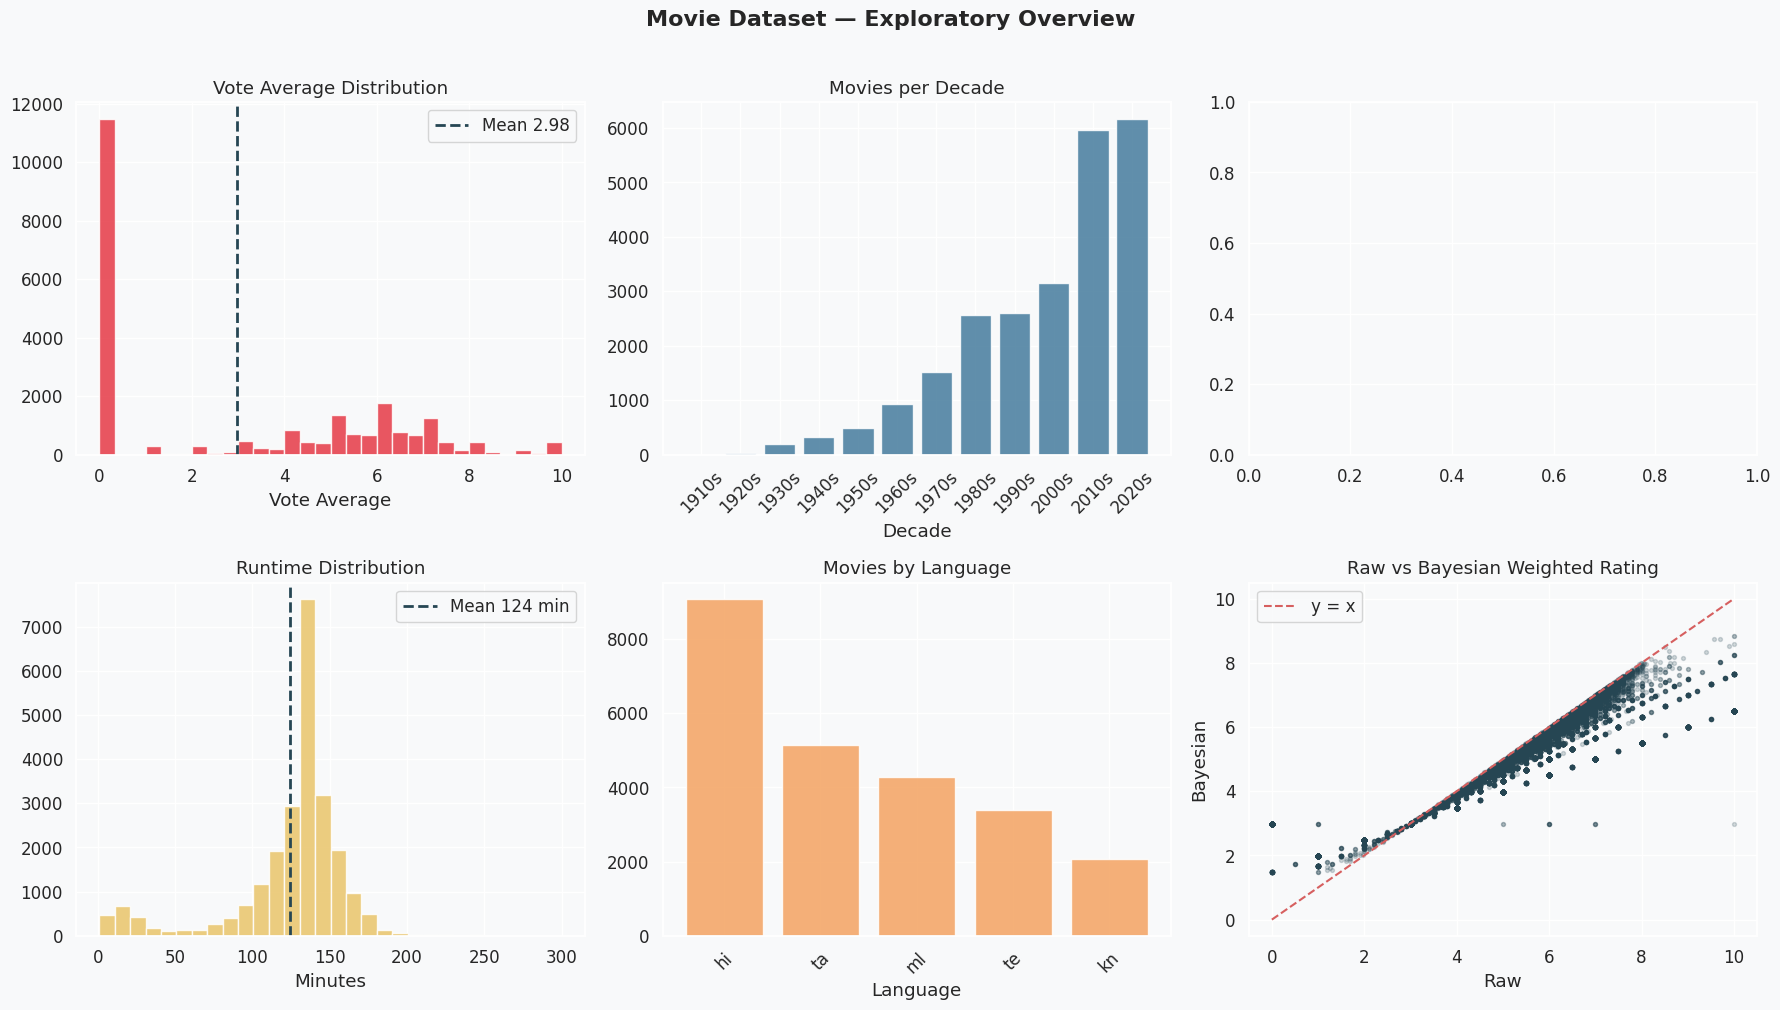

In [77]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Movie Dataset — Exploratory Overview', fontsize=16, fontweight='bold', y=1.01)

# 4.1 Rating distribution
ax = axes[0,0]
ax.hist(df['vote_average'], bins=30, color=PALETTE[0], edgecolor='white', alpha=.85)
ax.axvline(df['vote_average'].mean(), color='#264653', ls='--', lw=2,
           label=f"Mean {df['vote_average'].mean():.2f}")
ax.set_title('Vote Average Distribution'); ax.set_xlabel('Vote Average'); ax.legend()

# 4.2 Movies per decade
ax = axes[0,1]
decade_cnt = df['decade'].value_counts().sort_index()
ax.bar(decade_cnt.index, decade_cnt.values, color=PALETTE[1], edgecolor='white', alpha=.85)
ax.set_title('Movies per Decade'); ax.set_xlabel('Decade')
plt.setp(ax.get_xticklabels(), rotation=45)

# 4.3 Top 15 genres (primary)

# 4.4 Runtime distribution
ax = axes[1,0]
ax.hist(df['runtime'].clip(upper=300), bins=30, color=PALETTE[3], edgecolor='white', alpha=.85)
ax.axvline(df['runtime'].mean(), color='#264653', ls='--', lw=2,
           label=f"Mean {df['runtime'].mean():.0f} min")
ax.set_title('Runtime Distribution'); ax.set_xlabel('Minutes'); ax.legend()

# 4.5 Top languages
ax = axes[1,1]
top_lang = df['language'].value_counts().head(12)
ax.bar(top_lang.index, top_lang.values, color=PALETTE[4], edgecolor='white', alpha=.85)
ax.set_title('Movies by Language'); ax.set_xlabel('Language')
plt.setp(ax.get_xticklabels(), rotation=45)

# 4.6 Raw vs Bayesian rating
ax = axes[1,2]
ax.scatter(df['vote_average'], df['weighted_rating'], alpha=.2, s=8, color=PALETTE[5])
ax.plot([0,10],[0,10], 'r--', lw=1.5, label='y = x')
ax.set_title('Raw vs Bayesian Weighted Rating'); ax.set_xlabel('Raw'); ax.set_ylabel('Bayesian')
ax.legend()

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=140, bbox_inches='tight')
plt.show()


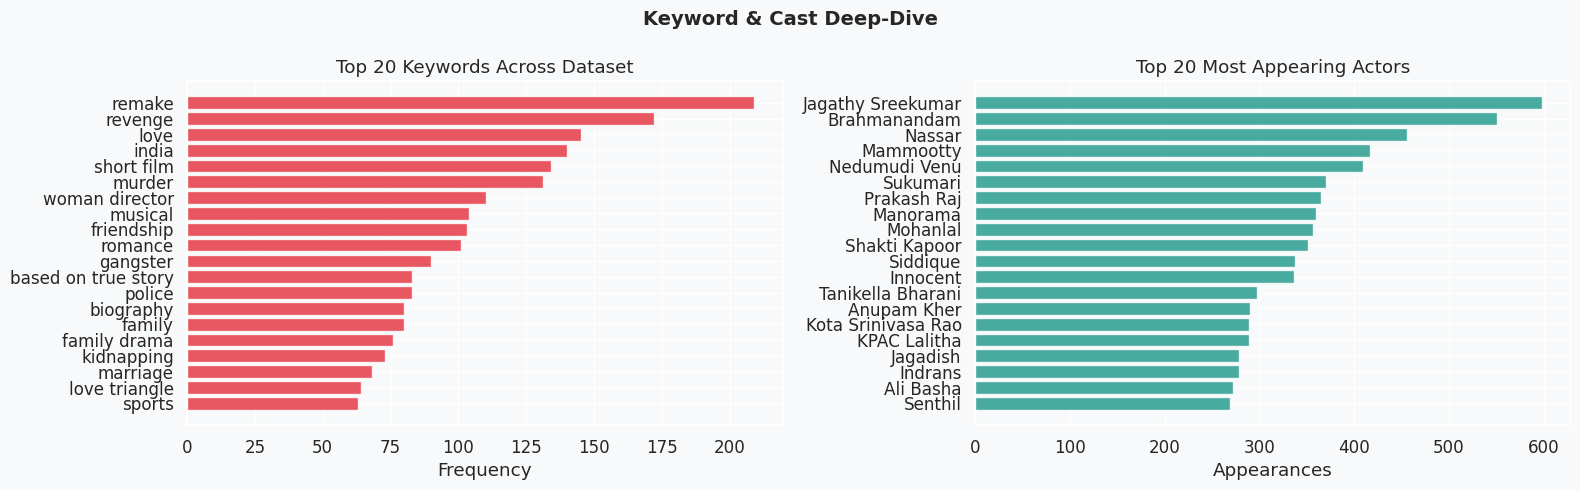

In [78]:
# ── Top keywords across the dataset ─────────────────────────────────────────
all_kw = [kw for kws in df['keywords'] for kw in kws]
kw_counts = Counter(all_kw).most_common(20)
kw_labels, kw_vals = zip(*kw_counts)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Keyword & Cast Deep-Dive', fontsize=14, fontweight='bold')

ax = axes[0]
ax.barh(list(kw_labels)[::-1], list(kw_vals)[::-1], color=PALETTE[0], alpha=.85)
ax.set_title('Top 20 Keywords Across Dataset'); ax.set_xlabel('Frequency')

# ── Top cast members ─────────────────────────────────────────────────────────
all_cast = [actor for actors in df['cast'] for actor in actors]
cast_counts = Counter(all_cast).most_common(20)
cast_labels, cast_vals = zip(*cast_counts)

ax = axes[1]
ax.barh(list(cast_labels)[::-1], list(cast_vals)[::-1], color=PALETTE[2], alpha=.85)
ax.set_title('Top 20 Most Appearing Actors'); ax.set_xlabel('Appearances')

plt.tight_layout()
plt.savefig('eda_keywords_cast.png', dpi=140, bbox_inches='tight')
plt.show()


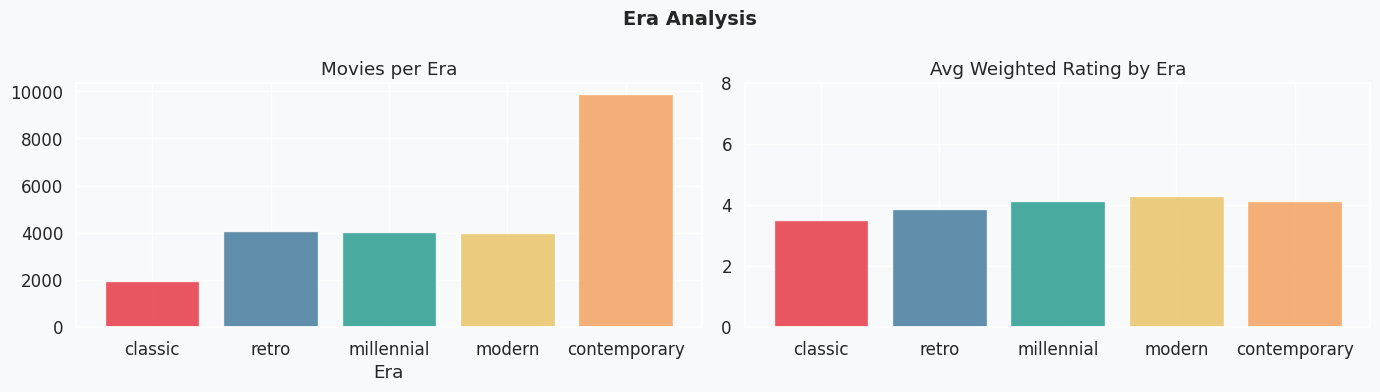


Era breakdown:
              weighted_rating  vote_count  keyword_count
era                                                     
classic                  3.52        0.92           0.24
contemporary             4.13        8.65           0.81
millennial               4.14        7.67           0.44
modern                   4.30       15.69           0.99
retro                    3.86        1.91           0.27


In [79]:
# ── Era distribution ─────────────────────────────────────────────────────────
era_order = ['classic', 'retro', 'millennial', 'modern', 'contemporary']
era_counts = df['era'].value_counts().reindex(era_order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Era Analysis', fontsize=14, fontweight='bold')

axes[0].bar(era_counts.index, era_counts.values, color=PALETTE[:5], edgecolor='white', alpha=.85)
axes[0].set_title('Movies per Era'); axes[0].set_xlabel('Era')

era_rating = df.groupby('era')['weighted_rating'].mean().reindex(era_order)
axes[1].bar(era_rating.index, era_rating.values, color=PALETTE[:5], edgecolor='white', alpha=.85)
axes[1].set_title('Avg Weighted Rating by Era'); axes[1].set_ylim(0, 8)

plt.tight_layout()
plt.savefig('eda_era.png', dpi=140, bbox_inches='tight')
plt.show()
print("\nEra breakdown:")
print(df.groupby('era')[['weighted_rating','vote_count','keyword_count']].mean().round(2))


## 5 · Soup Construction — Keyword-Heavy Weighting

The soup is the core feature string fed into TF-IDF.  
**Weighting strategy** (most important first):

| Feature | Weight (repeats) | Reason |
|---|---|---|
| `keywords` | ×3 | User-specified as most important signal |
| `overview` (tokenised) | ×2 | Narrative/plot context |
| `genres` | ×3 | Genre is the primary filter for most users |
| `cast_top5` | ×2 | Actor overlap drives strong co-watch behaviour |
| `director` | ×2 | Auteur signature |



In [80]:
df['overview'].str.split().apply(len).mean()

41.80322324746357

In [81]:
def clean_token(s: str) -> str:
    """Strip punctuation, lowercase, remove spaces — so 'Shah Rukh Khan' → 'shahrukhkhan'."""
    return re.sub(r'[^a-zA-Z0-9]', '', str(s)).lower()

def tokenise_text(text: str) -> str:
    """
    Tokenise free-form text (overview / tagline) for the soup.
    Removes stop-words, keeps meaningful tokens only.
    """
    STOP = {
        'a','an','the','and','or','but','is','are','was','were','be','been',
        'being','have','has','had','do','does','did','will','would','could',
        'should','may','might','shall','can','to','of','in','on','at','by',
        'for','with','about','as','into','through','his','her','their','its',
        'he','she','they','we','it','this','that','these','those','who','which',
        'when','where','how','what','not','no','nor','so','yet','both','either',
        'from','up','out','if','then','than','too','very','just','also'
    }
    tokens = re.findall(r'[a-zA-Z]{3,}', text.lower())
    filtered = [t for t in tokens if t not in STOP]
    return ' '.join(filtered[:])

def make_soup(row) -> str:
    """
    Build the weighted feature soup for TF-IDF.
    
    Weighting via repetition:
        keywords ×3  (most important - per specification)
        genres   ×3
        cast     ×2
        director ×1
        overview ×2  (plot context)
        
    """
    # ── Keywords ×3 (most important) ─────────────────────────────────────────
    kw_tokens    = ' '.join([clean_token(k) for k in row['keywords']])
    kw_weighted  = ' '.join([kw_tokens] * 3)

    # ── Genres ×3 ────────────────────────────────────────────────────────────
    genre_tokens   = ' '.join([clean_token(g) for g in row['genres']])
    genre_weighted = ' '.join([genre_tokens] * 3)

    # ── Cast (top 5) ×2 ──────────────────────────────────────────────────────
    cast_tokens   = ' '.join([clean_token(a) for a in row['cast']])
    cast_weighted = ' '.join([cast_tokens] * 2)

    # ── Director ×1 ──────────────────────────────────────────────────────────
    dir_token    = clean_token(row['director'])
    dir_weighted = f'{dir_token}'

    # ── Overview ×2 (tokenised) ───────────────────────────────────────────────
    overview_tokens  = tokenise_text(row['overview'])
    overview_weighted = f'{overview_tokens} {overview_tokens}'

    return (f"{kw_weighted} {genre_weighted} {cast_weighted} "
            f"{dir_weighted} {overview_weighted} ").strip()


def make_description(row) -> str:
    """
    Weighted natural-language description for SBERT.
    """

    # ── Prepare base strings ─────────────────────────
    genre_str = ', '.join(row['genres']) if row['genres'] else 'various genres'
    kw_str    = ', '.join(row['keywords']) if row['keywords'] else ''
    cast_str  = ', '.join(row['cast']) if row['cast'] else 'an ensemble cast'
    dir_str   = row['director'] if row['director'] != 'Unknown' else 'an unknown director'
    overview  = row['overview'] if row['overview'] else ''

    # ── Apply weights via repetition ─────────────────
    genre_part = ' '.join([genre_str] * 1)          
    keyword_part = ' '.join([kw_str] * 1)           
    cast_part = ' '.join([cast_str] * 1)            
    director_part = ' '.join([dir_str] * 1)         
    overview_part = overview                      

    # ── Build final description ─────────────────────
    desc = (
        f"A {genre_str} film released in {row['release_year']}. "
        f"This movie strongly belongs to the genres: {genre_part}. "
        f"Directed by {director_part} and starring {cast_part}. "
        )

    if overview_part:
        desc += f"{overview_part} "

    if keyword_part:
        desc += f"Key themes include: {keyword_part}."

    return desc.strip()
    
# ── Apply ────────────────────────────────────────────────────────────────────
df['soup']        = df.apply(make_soup,        axis=1)
df['description'] = df.apply(make_description, axis=1)

print("✅ Soup and description columns created")
print("\n— Sample Soup (first 200 chars):")
print(df['soup'].iloc[0][:200])
print("\n— Sample Description:")
print(df['description'].iloc[0][:300])


✅ Soup and description columns created

— Sample Soup (first 200 chars):
musical nostalgia loveinterest nostalgic wealthyfamily musical nostalgia loveinterest nostalgic wealthyfamily musical nostalgia loveinterest nostalgic wealthyfamily comedy drama family romance comedy 

— Sample Description:
A Comedy, Drama, Family, Romance film released in 2023. This movie strongly belongs to the genres: Comedy, Drama, Family, Romance. Directed by Karan Johar and starring Alia Bhatt, Ranveer Singh, Jaya Bachchan, Shabana Azmi, Dharmendra, Aamir Bashir, Tota Roy Chowdhury, Churni Ganguly, Kshitee Jog, A


## 6 · Content-Based Filtering (TF-IDF on Keyword-Heavy Soup)

In [82]:
# ── Build TF-IDF matrix ──────────────────────────────────────────────────────
tfidf = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    min_df=2,
    max_features=50_000,
    sublinear_tf=True,
)

tfidf_matrix = tfidf.fit_transform(df['soup'])
print(f"TF-IDF matrix shape : {tfidf_matrix.shape}")
print(f"Vocabulary size     : {len(tfidf.vocabulary_):,}")

# ── Lookup helpers ────────────────────────────────────────────────────────────
# Map lowercase title → DataFrame index for O(1) lookup
title_to_idx = pd.Series(df.index, index=df['title'].str.lower().str.strip())

def find_movie_idx(query: str, language: str = None) -> int:
    """
    Robust fuzzy lookup with duplicate-title handling.
    Search order: exact -> startswith -> contains.
    If language is provided and duplicates exist, prefer that language.
    """
    q = query.lower().strip()

    def pick_idx(indices_like):
        if isinstance(indices_like, pd.Series):
            indices = list(indices_like.values)
            if language:
                for i in indices:
                    if df.loc[i, 'language'] == language:
                        return int(i)
            return int(indices[0])
        return int(indices_like)

    # exact
    if q in title_to_idx.index:
        return pick_idx(title_to_idx[q])

    # startswith
    candidates = [k for k in title_to_idx.index if k.startswith(q)]
    if candidates:
        return pick_idx(title_to_idx[candidates[0]])

    # contains
    candidates = [k for k in title_to_idx.index if q in k]
    if candidates:
        return pick_idx(title_to_idx[candidates[0]])

    raise KeyError(f"Movie '{query}' not found in dataset.")

print("\n✅ TF-IDF content model ready.")
print(f"   Sample lookup — first title: '{df['title'].iloc[0]}'  -> idx {find_movie_idx(df['title'].iloc[0])}")

TF-IDF matrix shape : (23951, 50000)
Vocabulary size     : 50,000

✅ TF-IDF content model ready.
   Sample lookup — first title: 'Rocky Aur Rani Kii Prem Kahaani'  -> idx 0


In [100]:
def content_recommend(title: str, top_n: int = 10,
                      language_filter: str = None,
                      adult_filter: bool = None) -> pd.DataFrame:
    """Content recommendation using TF-IDF cosine with light quality blending."""
    idx = find_movie_idx(title, language=language_filter)

    cos_sim = linear_kernel(tfidf_matrix[idx], tfidf_matrix).flatten()
    cos_sim[idx] = 0

    candidate_df = df.copy()
    candidate_df['content_score'] = cos_sim

    # Year window around query movie
    query_year = df.loc[idx, 'release_year']
    candidate_df = candidate_df[
        (candidate_df['release_year'] >= query_year - 10) &
        (candidate_df['release_year'] <= query_year + 10)
    ]

    if language_filter:
        candidate_df = candidate_df[candidate_df['language'] == language_filter]
    if adult_filter is False:
        candidate_df = candidate_df[candidate_df['adult'] == False]

    candidate_df['weighted_rating_norm'] = candidate_df['weighted_rating'] / 10
    candidate_df = candidate_df[candidate_df['content_score'] > 0.05]

    candidate_df['final_score'] = (
        0.8 * candidate_df['content_score'] +
        0.2 * candidate_df['weighted_rating_norm']
    )

    top = candidate_df.nlargest(top_n, 'final_score')[
        ['title', 'release_year', 'era', 'genres',
         'vote_average', 'weighted_rating', 'language',
         'director', 'content_score', 'final_score']
    ].reset_index(drop=True)

    return top


sample_title = "Pushpa: The Rise"
idx = find_movie_idx(sample_title)
print("Input Movie:\n")
print(df.loc[idx, [
    'title', 'release_year', 'era', 'genres','keywords','cast',
    'vote_average', 'weighted_rating', 'language', 'director'
]])

print("\n" + "=" * 60 + "\n")
print(f"Content-based recommendations for: '{sample_title}'\n")

print(content_recommend(
    sample_title,
    top_n=8,
    language_filter='hi',
    adult_filter=False
).to_string(index=False))

Input Movie:

title                                                                   Pushpa: The Rise
release_year                                                                        2021
era                                                                         contemporary
genres                                                         [Action, Drama, Thriller]
keywords             [rags to riches, smugglers, sandalwood, egotistical, authoritarian]
cast               [Allu Arjun, Rashmika Mandanna, Jagadeesh Bandari, Sunil Varma, An...
vote_average                                                                       6.778
weighted_rating                                                                 6.757036
language                                                                              te
director                                                                         Sukumar
Name: 12232, dtype: object


Content-based recommendations for: 'Pushpa: The Rise'

            

## 7 · Semantic Filtering — Sentence-BERT on Overview + Keywords

In [84]:
# ── Build / load SBERT embeddings ────────────────────────────────────────────
# Encodes the full natural-language description (overview + keywords + cast)
# into 384-dim dense vectors that capture thematic/semantic proximity.

if SBERT_AVAILABLE:
    device     = 'cuda' if torch.cuda.is_available() else 'cpu'
    sbert      = SentenceTransformer('all-MiniLM-L6-v2', device=device)

    print(f"Encoding {len(df):,} movie descriptions on {device.upper()} ...")
    t0          = time.time()
    sbert_vecs  = sbert.encode(
        df['description'].tolist(),
        batch_size     = 128,
        show_progress_bar = True,
        normalize_embeddings = True   # cosine = dot product after L2-norm
    )
    print(f"✅ a embeddings shape: {sbert_vecs.shape}  ({time.time()-t0:.1f}s)")
else:
    sbert_vecs = None
    print("⚠️  SBERT unavailable — semantic_recommend will return empty results.")


Encoding 23,951 movie descriptions on CUDA ...


Batches: 100%|██████████| 188/188 [00:33<00:00,  5.68it/s]

✅ a embeddings shape: (23951, 384)  (33.4s)


In [121]:
def _jaccard(a: set, b: set) -> float:
    """Jaccard similarity with safe empty-set handling."""
    if not a and not b:
        return 0.0
    union = a | b
    if not union:
        return 0.0
    return len(a & b) / len(union)


def _is_clean_title(x: str) -> bool:
    """Filter obvious noisy titles (empty, numeric-only, single-symbol)."""
    t = str(x).strip()
    if len(t) < 2:
        return False
    if re.fullmatch(r"[0-9]+", t):
        return False
    if re.fullmatch(r"[^a-zA-Z0-9]+", t):
        return False
    return True


def semantic_recommend(title: str, top_n: int = 10,
                       language_filter: str = None,
                       adult_filter: bool = None,
                       year_window: int = 12,
                       min_genre_overlap: int = 1,
                       min_vote_count: int = 5) -> pd.DataFrame:
    """
    Improved semantic recommender:
    1) SBERT cosine for plot/theme similarity
    2) Genre/cast overlap to prevent semantic drift
    3) Soft temporal affinity for era consistency
    4) Quality priors to suppress noisy/weak candidates
    """
    if sbert_vecs is None:
        print("SBERT not available.")
        return pd.DataFrame()

    idx = find_movie_idx(title, language=language_filter)
    q_row = df.loc[idx]

    # SBERT cosine (embeddings are already L2-normalized)
    sbert_sim = (sbert_vecs @ sbert_vecs[idx]).flatten()
    sbert_sim[idx] = 0.0

    q_genres = set(q_row['genres']) if isinstance(q_row['genres'], list) else set()
    q_keywords = set(q_row['keywords']) if isinstance(q_row['keywords'], list) else set()
    q_cast = set(q_row['cast'][:5]) if isinstance(q_row['cast'], list) else set()
    q_year = int(q_row['release_year'])

    candidate_df = df.copy()
    candidate_df['sbert_raw'] = sbert_sim

    # Remove obvious noisy titles before scoring
    candidate_df = candidate_df[candidate_df['title'].apply(_is_clean_title)]

    # Lexical overlap guardrails
    candidate_df['genre_overlap'] = candidate_df['genres'].apply(
        lambda g: len(q_genres & set(g)) if isinstance(g, list) else 0
    )
    candidate_df['genre_jaccard'] = candidate_df['genres'].apply(
        lambda g: _jaccard(q_genres, set(g)) if isinstance(g, list) else 0.0
    )
    candidate_df['keyword_jaccard'] = candidate_df['keywords'].apply(
        lambda k: _jaccard(q_keywords, set(k)) if isinstance(k, list) else 0.0
    )
    candidate_df['cast_jaccard'] = candidate_df['cast'].apply(
        lambda c: _jaccard(q_cast, set(c[:5])) if isinstance(c, list) else 0.0
    )

    # Soft temporal affinity (keeps era closer without hard-killing neighbors)
    year_diff = np.abs(candidate_df['release_year'] - q_year)
    candidate_df['temporal_soft'] = np.exp(-(year_diff ** 2) / (2 * (max(year_window, 1) ** 2)))

    # Confidence/quality terms
    vc = candidate_df['vote_count'].astype(float).clip(lower=0)
    candidate_df['vote_confidence'] = np.log1p(vc) / np.log1p(vc.max() + 1e-9)
    candidate_df['rating_norm'] = candidate_df['weighted_rating'].astype(float).clip(lower=0, upper=10) / 10.0

    # Final semantic score: semantic + structure + time + quality
    candidate_df['semantic_score'] = (
        0.50 * candidate_df['sbert_raw'] +
        0.18 * candidate_df['genre_jaccard'] +
        0.10 * candidate_df['cast_jaccard'] +
        0.04 * candidate_df['keyword_jaccard'] +
        0.05 * candidate_df['temporal_soft'] +
        0.05 * candidate_df['vote_confidence'] +
        0.04 * candidate_df['rating_norm']
    )

    # Exclude the query movie itself
    if idx in candidate_df.index:
        candidate_df.loc[idx, 'semantic_score'] = 0.0

    # Optional filters
    if language_filter:
        candidate_df = candidate_df[candidate_df['language'] == language_filter]
    if adult_filter is False:
        candidate_df = candidate_df[candidate_df['adult'] == False]

    # Hard minimum genre alignment (if query has genre labels)
    if q_genres:
        candidate_df = candidate_df[candidate_df['genre_overlap'] >= min_genre_overlap]

    # Avoid ultra-low confidence rows unless we have too few candidates
    confident_df = candidate_df[candidate_df['vote_count'] >= min_vote_count]
    if len(confident_df) >= top_n:
        candidate_df = confident_df

    # Hard year window to avoid extreme vintage drift
    if year_window is not None:
        in_window = candidate_df[np.abs(candidate_df['release_year'] - q_year) <= year_window]
        if len(in_window) >= top_n:
            candidate_df = in_window

    # Fallback if too restrictive
    if len(candidate_df) < top_n:
        relaxed_df = df.copy()
        relaxed_df = relaxed_df[relaxed_df['title'].apply(_is_clean_title)]
        relaxed_df['semantic_score'] = (
            0.78 * sbert_sim +
            0.12 * relaxed_df['genres'].apply(
                lambda g: _jaccard(q_genres, set(g)) if isinstance(g, list) else 0.0
            ) +
            0.05 * relaxed_df['cast'].apply(
                lambda c: _jaccard(q_cast, set(c[:5])) if isinstance(c, list) else 0.0
            ) +
            0.05 * (relaxed_df['weighted_rating'].astype(float).clip(0, 10) / 10.0)
        )
        if idx in relaxed_df.index:
            relaxed_df.loc[idx, 'semantic_score'] = 0.0
        if language_filter:
            relaxed_df = relaxed_df[relaxed_df['language'] == language_filter]
        if adult_filter is False:
            relaxed_df = relaxed_df[relaxed_df['adult'] == False]
        candidate_df = relaxed_df

    top = candidate_df.nlargest(top_n, 'semantic_score')[
        ['title', 'release_year', 'era', 'genres', 'vote_average',
         'vote_count', 'weighted_rating', 'language', 'genre_overlap',
         'genre_jaccard', 'cast_jaccard', 'keyword_jaccard',
         'vote_confidence', 'semantic_score']
    ].reset_index(drop=True)
    return top


# ── Test ──────────────────────────────────────────────────────────────────────
if SBERT_AVAILABLE:
    sample_title = "PK"

    idx = find_movie_idx(sample_title)
    row = df.loc[idx]

    print("Input Movie Details:\n")
    print("Title     :", row['title'])
    print("Genres    :", ', '.join(row['genres']))
    print("Keywords  :", ', '.join(row['keywords'][:10]))
    print("Language  :", row['language'])

    print(f"\nImproved semantic recommendations for: '{sample_title}'\n")
    print(
        semantic_recommend(
            sample_title,
            top_n=10,
            adult_filter=False,
            year_window=12,
            min_genre_overlap=1,
            min_vote_count=5
        ).to_string(index=False)
    )

Input Movie Details:

Title     : PK
Genres    : Comedy, Drama, Science Fiction
Keywords  : friendship, society, christianity, hinduism, islam, satire, alien, love, religion, sociology
Language  : hi

Improved semantic recommendations for: 'PK'

                     title  release_year          era                   genres  vote_average  vote_count  weighted_rating language  genre_overlap  genre_jaccard  cast_jaccard  keyword_jaccard  vote_confidence  semantic_score
  Lipstick Under My Burkha          2017 contemporary          [Comedy, Drama]         6.811         106         6.775229       hi              2       0.666667      0.000000         0.041667         0.554446        0.585288
                Anbe Sivam          2003   millennial          [Comedy, Drama]         7.611          81         7.554567       ta              2       0.666667      0.000000         0.000000         0.522871        0.578845
        Bhoothnath Returns          2014       modern [Comedy, Drama, Fantasy] 

## 9 · Collaborative Filtering — SVD on Keyword Co-occurrence Matrix

In [102]:
# ── Build keyword co-occurrence matrix ───────────────────────────────────────
# Since we have no explicit user ratings, we build a movie × keyword binary matrix.
# TruncatedSVD finds latent thematic factors (analogous to latent user preferences).
# KNN in the latent space surfaces movies that share latent topic patterns.

print("Building keyword co-occurrence matrix...")

# Use CountVectorizer on keywords only (no repeating) for pure CF signal
cv = CountVectorizer(
    analyzer     = 'word',
    ngram_range  = (1, 1),
    min_df       = 2,
    max_features = 15_000
)

# Encode keywords + genres as a clean bag-of-words (no soup weighting here)
kw_text = df.apply(
    lambda r: ' '.join([clean_token(k) for k in r['keywords']] +
                       [clean_token(g) for g in r['genres']]+ [clean_token(a) for a in r['cast']]
                       ),
    axis=1
)
kw_matrix = cv.fit_transform(kw_text)
print(f"Keyword matrix shape : {kw_matrix.shape}")

# ── SVD dimensionality reduction ─────────────────────────────────────────────
N_COMPONENTS = min(1500, kw_matrix.shape[1] - 1)
svd          = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
movie_vecs   = svd.fit_transform(kw_matrix)   # (n_movies, 150)

explained = svd.explained_variance_ratio_.sum()
print(f"SVD variance explained: {explained:.2%}  ({N_COMPONENTS} components)")

# ── K-Nearest Neighbours in SVD latent space ─────────────────────────────────
knn = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=50)
knn.fit(movie_vecs)
print("✅ CF model (SVD + KNN) ready.")


Building keyword co-occurrence matrix...
Keyword matrix shape : (23951, 12475)
SVD variance explained: 71.30%  (1500 components)
✅ CF model (SVD + KNN) ready.


In [103]:
def cf_recommend(title: str, top_n: int = 10,
                 language_filter: str = None,
                 adult_filter:    bool = None) -> pd.DataFrame:
    """
    Collaborative-style recommendation via SVD latent space + KNN.
    Surfaces movies that share latent topic/keyword patterns.
    """
    idx       = find_movie_idx(title)
    dists, nn_idx = knn.kneighbors(movie_vecs[idx].reshape(1, -1), n_neighbors=50)

    # Convert cosine distance → similarity
    nn_idx    = nn_idx.flatten()
    nn_sim    = (1 - dists.flatten())

    candidate_df              = df.iloc[nn_idx].copy()
    candidate_df['cf_score']  = nn_sim
    candidate_df              = candidate_df[candidate_df.index != idx]

    if language_filter:
        candidate_df = candidate_df[candidate_df['language'] == language_filter]
    if adult_filter is False:
        candidate_df = candidate_df[candidate_df['adult'] == False]

    top = candidate_df.nlargest(top_n, 'cf_score')[
        ['title','release_year','era','primary_genre','vote_average',
         'weighted_rating','language','cf_score']
    ].reset_index(drop=True)
    return top


# ── Test ──────────────────────────────────────────────────────────────────────
sample_title = "Pushpa: The Rise"
print(f"CF recommendations for: '{sample_title}'\n")
print(cf_recommend(sample_title, top_n=8).to_string(index=False))


CF recommendations for: 'Pushpa: The Rise'

              title  release_year          era primary_genre  vote_average  weighted_rating language  cf_score
Pushpa 2 - The Rule          2024 contemporary        Action         6.285         6.260724       te  0.843409
       Tamizhananen          2018 contemporary        Action         0.000         2.983497       ta  0.502716
             Abbara          2022 contemporary        Action         0.000         2.983497       kn  0.501835
           Randhawa          2019 contemporary        Action         0.000         2.983497       kn  0.495467
             Vasham          2017 contemporary      Thriller         0.000         2.983497       te  0.492592
         Fight Club          2023 contemporary        Action         6.600         6.387265       ta  0.490831
        Blood Money          2012       modern         Drama         6.100         5.788350       hi  0.461598
    Rudramambapuram          2023 contemporary         Drama        